In [1]:
import pandas as pd
import pickle
import numpy as np
import time
import random
import igraph as ig
from IPython.display import display, clear_output
from SOINN import SOINN

In [2]:
def run_train(s, data, y_train):
    xs = []
    n_nodes = []
    n_edges = []
    n_del_nodes = []
    n_del_edges = []

    start_time = time.time()

    for index, row in data.iterrows():
        x = row.values
        y = y_train[index]
        s.input_signal(x, y, learning=True)
        # print completed percentage
        percent_completed = round((index / len(data))*100, 2)
        if index % 100 == 0 or index == len(data):
            clear_output(wait=True)
            print(f'Processing input {index}: {percent_completed}% completed')
            n_nodes.append(s.network.vcount())
            n_edges.append(s.network.ecount())
            n_del_nodes.append(s.n_del_nodes)
            n_del_edges.append(s.n_del_edges)
            xs.append(index)

    finish_time = round(time.time() - start_time)
    mins = round(finish_time / 60)
    secs = finish_time % 60

    clear_output(wait=True)
    print(f'Training time: {mins} min {secs} sec')
    print(f'Inputs processed: {index}')

    n_v = s.network.vcount()
    n_e = s.network.ecount()
    print(f'Number of nodes: {n_v}')
    print(f'Number of edges: {n_e}')

    return xs, n_nodes, n_edges, n_del_nodes, n_del_edges

In [3]:
def run_test(s, data, y_test):
    n_errors = 0
    n_false_alarms = 0
    n_non_detected_attacks = 0
    predicted = []

    for index, row in data.iterrows():
        x = row.values
        y = y_test[index]
        yp = s.input_signal(x, learning=False)
        # append predicted label for later visualization
        predicted.append(yp)
        if y != yp:
            n_errors += 1
        if y != yp and (y == 'normal' and yp != 'normal'):
            n_false_alarms += 1
        if y != yp and (y != 'normal' and yp == 'normal'):
            n_non_detected_attacks += 1
        # print completed percentage
        percent_completed = round((index / len(data))*100, 2)
        if index % 100 == 0 or index == len(data):
            clear_output(wait=True)
            print(f'Predictions completed: {percent_completed}%')

    clear_output(wait=True)
    print(f'Inputs processed: {index}')
    p1 = round((1 - (n_errors / index))*100, 2)
    p2 = round((n_false_alarms / index)*100, 2)
    p3 = round((1 - (n_non_detected_attacks / index))*100, 2)
    print(f'Overall accuracy: {p1}%')
    print(f'False alarms: {p2}%')
    print(f'Detected attacks: {p3}%')

    errors_freq = dict()
    for i in range(len(y_test)):
        if y_test[i] != predicted[i]:
            errors_freq[f'{y_test[i]}-{predicted[i]}'] = 0

    for i in range(len(y_test)):
        if y_test[i] != predicted[i]:
            #print(f'Prediction given {y_test[i]}: {predicted[i]}')
            errors_freq[f'{y_test[i]}-{predicted[i]}'] += 1

    # sort frequency dictionary
    errors_freq = dict(sorted(errors_freq.items(), key=itemgetter(1)))
    print('\n\n')
    print(errors_freq)

In [4]:
normal = pd.read_csv('./MQTT-IoT-IDS2020/biflow_normal.csv')
bruteforce = pd.read_csv('./MQTT-IoT-IDS2020/biflow_mqtt_bruteforce.csv')
scan_a = pd.read_csv('./MQTT-IoT-IDS2020/biflow_scan_A.csv')
scan_su = pd.read_csv('./MQTT-IoT-IDS2020/biflow_scan_sU.csv')
sparta = pd.read_csv('./MQTT-IoT-IDS2020/biflow_sparta.csv')

# one-hot encoding for the source and destination ips
normal = pd.get_dummies(normal, columns=['ip_src', 'ip_dst'])
bruteforce = pd.get_dummies(bruteforce, columns=['ip_src', 'ip_dst'])
scan_a = pd.get_dummies(scan_a, columns=['ip_src', 'ip_dst'])
scan_su = pd.get_dummies(scan_su, columns=['ip_src', 'ip_dst'])
sparta = pd.get_dummies(sparta, columns=['ip_src', 'ip_dst'])

print(f'Normal connections: {len(normal)}')
print(f'MQTT bruteforce connections: {len(bruteforce)}')
print(f'Scan A connections: {len(scan_a)}')
print(f'Scan sU connections: {len(scan_su)}')
print(f'Sparta connections: {len(sparta)}')

Normal connections: 86008
MQTT bruteforce connections: 16696
Scan A connections: 25693
Scan sU connections: 39664
Sparta connections: 91318


In [5]:
y_normal = normal['is_attack'].values
del normal['is_attack']

y_bruteforce = bruteforce['is_attack'].values
del bruteforce['is_attack']

y_scan_a = scan_a['is_attack'].values
del scan_a['is_attack']

y_scan_su = scan_su['is_attack'].values
del scan_su['is_attack']

y_sparta = sparta['is_attack'].values
del sparta['is_attack']

In [6]:
# testing and training data splitting
normal_train = normal[:10000]
normal_test = normal[10000:]
y_normal_train = y_normal[:10000]
y_normal_test = y_normal[10000:]

bruteforce_train = bruteforce[:10000]
bruteforce_train = bruteforce[10000:]
y_bruteforce_train = y_bruteforce[:10000]
y_bruteforce_test = y_bruteforce[10000:]

scan_a_train = scan_a[:10000]
scan_a_test = scan_a[10000:]
y_scan_a_train = y_scan_a[:10000]
y_scan_a_test = y_scan_a[10000:]

scan_su_train = scan_su[:10000]
scan_su_test = scan_su[10000:]
y_scan_su_train = y_scan_su[:10000]
y_scan_su_test = y_scan_su[10000:]

sparta_train = sparta[:10000]
sparta_test = sparta[10000:]
y_sparta_train = y_sparta[:10000]
y_sparta_test = y_sparta[10000:]

In [7]:
rand_int = random.randint(1, len(normal) - 1)
x1 = normal.iloc[rand_int].values
rand_int = random.randint(1, len(normal) - 1)
x2 = normal.iloc[rand_int].values
rand_int = random.randint(1, len(normal) - 1)
x3 = normal.iloc[rand_int].values

s = SOINN.SOINN(x1, x2, x3, max_edge_age=len(normal), iter_lambda=50)

xs, n_nodes, n_edges, n_del_nodes, n_del_edges = run_train(s, data=normal_train, y_train=y_normal_train)

Training time: 0 min 7 sec
Inputs processed: 9999
Number of nodes: 42
Number of edges: 41


In [8]:
run_test(s, data=normal_test, y_test=y_normal_test)

Predictions completed: 99.99%


IndexError: index 76008 is out of bounds for axis 0 with size 76008

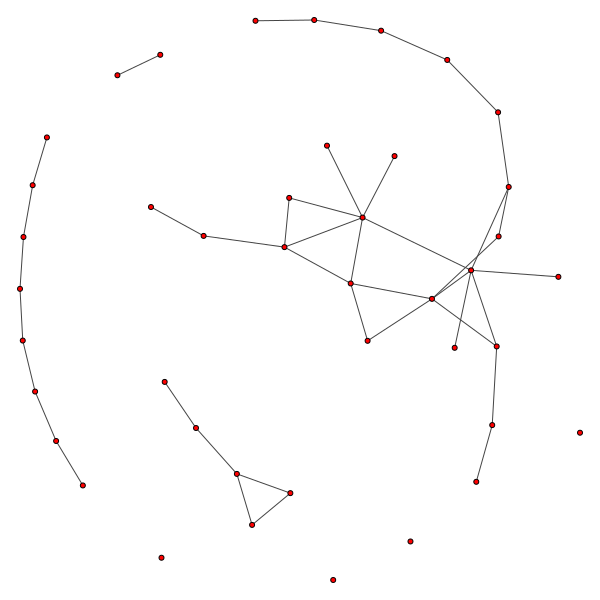

In [11]:
i = 0
color_dict = dict()
classes = np.unique(y_normal_train)
palette = ig.ClusterColoringPalette(len(classes))
for c in classes:
    color_dict[c] = palette[i]
    i += 1

ig.plot(s.network, vertex_size=5, vertex_color=[color_dict[c] for c in s.network.vs['cl']])